# Creación de Datasets

## General

Verificaciones del repositorio de datos

In [1]:
import os
import json

dataset_path = "data/manifestations_raw"
all_ttps = []

for step_dir in os.listdir(os.path.join(dataset_path, "steps")):
    step_path = os.path.join(dataset_path, "steps", step_dir)
    if os.path.exists(os.path.join(step_path, "attacker/logs/attackmate.json")):
        ttps = []
        with open(os.path.join(step_path, "attacker/logs/attackmate.json")) as f:
            for l in f:
                attackmate_data = json.loads(l)
                param = attackmate_data.get("parameters", {})
                metadata = param.get("metadata", {}) if param else {}
                techniques = metadata.get("techniques", []) if metadata else []

                possible_ttps = techniques.strip().split(",") if isinstance(techniques, str) else []
                if len(possible_ttps) > 0:
                    ttps.append(possible_ttps)
        all_ttps.append(ttps)

inconsistencies = []
for e in all_ttps:
    if len(e) > 1:
        # Comprobar que los elementos de la lista son iguales
        if not all(x == e[0] for x in e):
            inconsistencies.append(e)
if len(inconsistencies) > 0:
    print("Se han encontrado inconsistencias en los ttps:")
    for inc in inconsistencies:
        print(inc)

else:
    print("No se han encontrado inconsistencias en los ttps.")

# Buscar todos los archivos dentro de un directorio que su ruta acabe en alerts.json
paths = []

for root, dirs, files in os.walk(os.path.join(dataset_path, "steps")):
    for file in files:
        if file == "alerts.json":
            alert_file_path = os.path.join(root, file)
            paths.append(alert_file_path)

different_paths = []
for p in paths:
    if not p.endswith("wazuh\\logs\\alerts\\alerts.json"):
        different_paths.append(p)

if len(different_paths) > 0:
    print("Se han encontrado rutas diferentes a wazuh\\logs\\alerts\\alerts.json:")
    for dp in different_paths:
        print(dp)

else:
    print("Todas las rutas de alertas acaban en wazuh\\logs\\alerts\\alerts.json.")

# Buscar todos los archivos dentro de un directorio que su ruta acabe en alerts.json
paths = []

for root, dirs, files in os.walk(os.path.join(dataset_path, "steps")):
    for file in files:
        if file == "attackmate.json":
            alert_file_path = os.path.join(root, file)
            paths.append(alert_file_path)

different_paths = []
for p in paths:
    if not p.endswith("attacker\\logs\\attackmate.json"):
        different_paths.append(p)

if len(different_paths) > 0:
    print("Se han encontrado rutas diferentes a attacker\\logs\\attackmate.json:")
    for dp in different_paths:
        print(dp)

else:
    print("Todas las rutas de attackmate acaban en attacker\\logs\\attackmate.json.")

No se han encontrado inconsistencias en los ttps.
Todas las rutas de alertas acaban en wazuh\logs\alerts\alerts.json.
Todas las rutas de attackmate acaban en attacker\logs\attackmate.json.


Creación del CSV con todas las alertas

In [2]:
import csv
import json
import os

dataset_path = "data/manifestations_raw"
alerts_with_truth = []
paths_to_save = []

with open('data/alerts_dataset.csv', 'w') as csvfile:
    writer = csv.writer(csvfile)

    writer.writerow(["alert", "real_ttps", "possible_ttps", "scenario", "step", "alert_path"])  
    
    for step_dir in os.listdir(os.path.join(dataset_path, "steps")):
        step_path = os.path.join(dataset_path, "steps", step_dir)
        scenario, step = step_dir.split("-")
        if os.path.exists(os.path.join(step_path, "attacker/logs/attackmate.json")):
            paths_to_save.append(os.path.join(step_path, "attacker/logs/attackmate.json"))
            ttps = []
            with open(os.path.join(step_path, "attacker/logs/attackmate.json")) as f:
                for l in f:
                    attackmate_data = json.loads(l)
                    param = attackmate_data.get("parameters", {})
                    metadata = param.get("metadata", {}) if param else {}
                    techniques = metadata.get("techniques", []) if metadata else []

                    possible_ttps = techniques.strip().split(",") if isinstance(techniques, str) else []
                    if len(possible_ttps) > 0:
                        ttps.extend(possible_ttps)
                        continue  # Si encontramos técnicas, no necesitamos buscar más en este paso (se comprobó que coinciden si hay más de una línea que contenga)

            if os.path.exists(os.path.join(step_path, "wazuh/logs/alerts/alerts.json")):
                paths_to_save.append(os.path.join(step_path, "wazuh/logs/alerts/alerts.json"))
                with open(os.path.join(step_path, "wazuh/logs/alerts/alerts.json")) as f:
                    for line in f:
                        alert_data = json.loads(line)
                        real_ttps = alert_data.get('rule', {}).get('mitre', {}).get('id', [])
                        
                        writer.writerow([json.dumps(alert_data), real_ttps, ttps, scenario, step, os.path.join(step_path, "wazuh/logs/alerts/alerts.json")])
                

In [1]:
import pandas as pd

df = pd.read_csv('data/alerts_dataset.csv')

df.head()

,alert,real_ttps,possible_ttps,scenario,step,alert_path
0,"{""timestamp"": ""2025-09-22T18:37:00.601+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...
1,"{""timestamp"": ""2025-09-22T18:37:06.758+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...
2,"{""timestamp"": ""2025-09-22T18:37:06.774+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...
3,"{""timestamp"": ""2025-09-22T18:37:10.786+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...
4,"{""timestamp"": ""2025-09-22T18:37:12.713+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...


Comprobaciones de etiquetas explícitas

In [7]:
df['real_ttps'].value_counts()

real_ttps
[]                             220584
['T1595.002']                   14209
['T1055', 'T1083', 'T1190']      5201
['T1059.007']                    3791
['T1055', 'T1083']                566
['T1059']                         411
['T1078']                         290
['T1055']                         248
['T1548.003']                     196
['T1057']                          91
['T1190']                          57
['T1078', 'T1021']                 47
['T1499']                          35
['T1210']                          35
['T1083']                          13
['T1136']                          12
['T1562.001']                       3
['T1040']                           2
Name: count, dtype: int64

Extracción de campos de la alerta a columnas propias

In [8]:
import json
parsed_alerts = []

for alert in df.alert:
    alert_data = json.loads(alert)
    timestamp = alert_data.get("timestamp", "")
    rule = alert_data.get("rule", {})
    level = rule.get("level", "")
    desc = rule.get("description", "")
    rule_id = rule.get("id", "")
    fired_times = rule.get("firedtimes", "")
    groups = rule.get("groups", [])
    agent = alert_data.get("agent", {})
    manager = alert_data.get("manager", {})
    alert_id = alert_data.get("id", "")
    log = alert_data.get("full_log", "")
    log_data = alert_data.get("data", {})

    parsed_alerts.append([timestamp, level, desc, rule_id, fired_times, groups, agent, manager, alert_id, log, log_data])

df[["timestamp", "level", "description", "rule_id", "fired_times", "groups", "agent", "manager", "alert_id", "full_log", "data"]] = pd.DataFrame(parsed_alerts, index=df.index)


In [9]:
df.head()

,alert,real_ttps,possible_ttps,scenario,step,alert_path,timestamp,level,description,rule_id,fired_times,groups,agent,manager,alert_id,full_log,data
0,"{""timestamp"": ""2025-09-22T18:37:00.601+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:00.601+0000,6,Processes running for all users were queried w...,92604,1,[audit_detections],"{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566220.11498102,type=SYSCALL msg=audit(1758566218.934:4968): a...,"{'audit': {'type': 'SYSCALL', 'id': '4968', 'a..."
1,"{""timestamp"": ""2025-09-22T18:37:06.758+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:06.758+0000,7,Agent event queue is 90% full.,202,4,"[wazuh, agent_flooding]","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566226.11500168,wazuh: Agent buffer: '90%'.,{'level': '90%'}
2,"{""timestamp"": ""2025-09-22T18:37:06.774+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:06.774+0000,9,Agent event queue is full. Events may be lost.,203,7,"[wazuh, agent_flooding]","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566226.11500400,wazuh: Agent buffer: 'full'.,{'level': 'full'}
3,"{""timestamp"": ""2025-09-22T18:37:10.786+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:10.786+0000,9,Agent event queue is full. Events may be lost.,203,8,"[wazuh, agent_flooding]","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566230.11500650,wazuh: Agent buffer: 'full'.,{'level': 'full'}
4,"{""timestamp"": ""2025-09-22T18:37:12.713+0000"", ...",[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:12.713+0000,9,Agent event queue is full. Events may be lost.,203,9,"[wazuh, agent_flooding]","{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566232.11500900,wazuh: Agent buffer: 'full'.,{'level': 'full'}


Guardado en CSV 'alerts_dataset_parsed'

In [4]:
df.to_csv('data/alerts_dataset_parsed.csv', index=False)

Selección de las alertas con TTPs mapeados explícitamente (reglas Wazuh)

In [10]:
alerts_with_ttp = df[df['real_ttps'] != '[]']
alerts_with_ttp

,alert,real_ttps,possible_ttps,scenario,step,alert_path,timestamp,level,description,rule_id,fired_times,groups,agent,manager,alert_id,full_log,data
0,"{""timestamp"": ""2025-09-22T18:37:00.601+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:00.601+0000,6,Processes running for all users were queried w...,92604,1,[audit_detections],"{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566220.11498102,type=SYSCALL msg=audit(1758566218.934:4968): a...,"{'audit': {'type': 'SYSCALL', 'id': '4968', 'a..."
7,"{""timestamp"": ""2025-09-22T18:37:18.892+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:18.892+0000,6,Processes running for all users were queried w...,92604,2,[audit_detections],"{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566238.11501650,type=SYSCALL msg=audit(1758566228.862:6639): a...,"{'audit': {'type': 'SYSCALL', 'id': '6639', 'a..."
9,"{""timestamp"": ""2025-09-22T18:37:20.423+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:20.423+0000,6,Processes running for all users were queried w...,92604,3,[audit_detections],"{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566240.11503968,type=SYSCALL msg=audit(1758566230.022:7251): a...,"{'audit': {'type': 'SYSCALL', 'id': '7251', 'a..."
10,"{""timestamp"": ""2025-09-22T18:37:20.424+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:20.424+0000,6,Processes running for all users were queried w...,92604,4,[audit_detections],"{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566240.11506032,type=SYSCALL msg=audit(1758566230.034:7253): a...,"{'audit': {'type': 'SYSCALL', 'id': '7253', 'a..."
11,"{""timestamp"": ""2025-09-22T18:37:20.458+0000"", ...",['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ...",1_autostart_localaccount,13,data/manifestations_raw\steps\1_autostart_loca...,2025-09-22T18:37:20.458+0000,6,Processes running for all users were queried w...,92604,5,[audit_detections],"{'id': '002', 'name': 'videoserver', 'ip': '17...",{'name': 'wazuh'},1758566240.11508098,type=SYSCALL msg=audit(1758566230.062:7266): a...,"{'audit': {'type': 'SYSCALL', 'id': '7266', 'a..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245496,"{""timestamp"": ""2025-12-15T11:05:46.800+0000"", ...",['T1078'],['T1548.003'],4,8,data/manifestations_raw\steps\4-8\wazuh/logs/a...,2025-12-15T11:05:46.800+0000,3,PAM: Login session opened.,5501,8,"[pam, syslog, authentication_success]","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1765796746.964890,Dec 15 11:05:46 inetfw sudo[4160]: pam_unix(su...,"{'srcuser': 'john', 'dstuser': 'root(uid=0)', ..."
245499,"{""timestamp"": ""2025-12-15T11:06:02.749+0000"", ...",['T1548.003'],"['T1036.005', 'T1205.001']",4,9,data/manifestations_raw\steps\4-9\wazuh/logs/a...,2025-12-15T11:06:02.749+0000,4,First time user executed sudo.,5403,3,"[syslog, sudo]","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1765796762.966967,Dec 15 11:06:01 inetfw sudo: root : TTY=pt...,"{'srcuser': 'root', 'dstuser': 'root', 'tty': ..."
245500,"{""timestamp"": ""2025-12-15T11:06:02.763+0000"", ...",['T1078'],"['T1036.005', 'T1205.001']",4,9,data/manifestations_raw\steps\4-9\wazuh/logs/a...,2025-12-15T11:06:02.763+0000,3,PAM: Login session opened.,5501,9,"[pam, syslog, authentication_success]","{'id': '001', 'name': 'inetfw', 'ip': '192.168...",{'name': 'wazuh'},1765796762.967345,Dec 15 11:06:01 inetfw sudo: pam_unix(sudo:ses...,"{'srcuser': 'john', 

Visualización de la distribución de las etiquetas

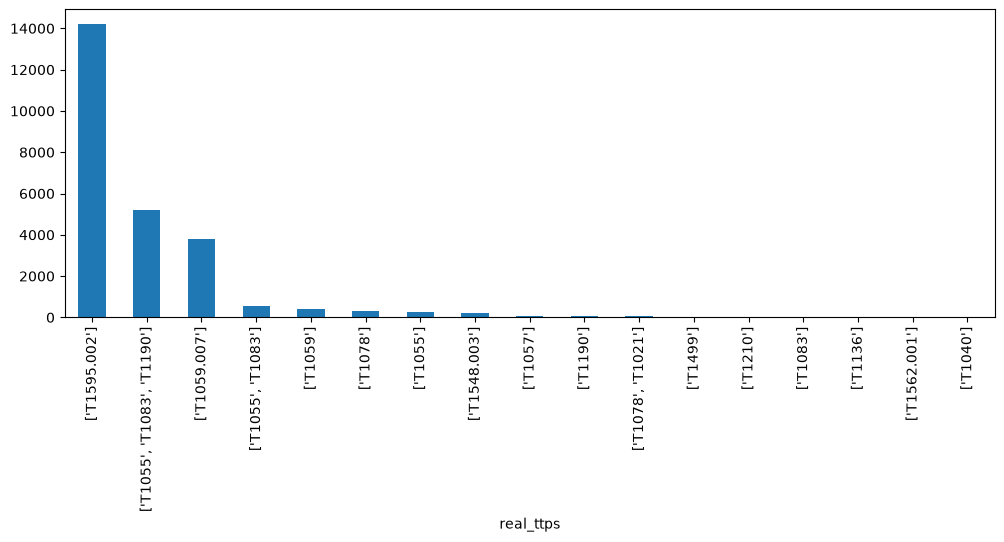

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))

alerts_with_ttp['real_ttps'].value_counts().plot(kind='bar')

plt.show()

Creación de un subconjunto con una alerta de cada tipo y guardado en el CSV 'unique_alerts'

In [ ]:
# Crear un dataset con una alerta de cada descripción de alerta
unique_alerts = alerts_with_ttp.drop_duplicates(subset=['description'])

unique_alerts.to_csv('data/unique_alerts.csv', index=False)

Eliminación del campo explícito de MITRE en las alertas para que el modelo no lo pueda leer

In [ ]:
import pandas as pd
import json

def remove_ttp(alert):
    alert = json.loads(alert)
    key_path = ['rule', 'mitre']  
    parent = alert
    for key in key_path[:-1]:
        parent = parent.get(key, {})
        if not isinstance(parent, dict):
            parent = {}
            break
    parent.pop(key_path[-1], None)
    return json.dumps(alert)

df = pd.read_csv('data/unique_alerts.csv', parse_dates=['timestamp'])
df['alert'] = df.alert.apply(remove_ttp)
df.to_csv('data/unique_alerts.csv', index=False)

Creación de dataset con alertas únicas y su ventana de contexto de alrededor y guardado en CSV 'unique'

In [ ]:
import pandas as pd

def obtener_alertas_con_contexto(ruta_archivo, ruta_salida, ventana=5):
    # Cargar el dataset
    df = pd.read_csv(ruta_archivo)
    
    # Ordenar por timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # Obtener el índice de la primera aparición de cada descripción única
    indices_unicos = df.drop_duplicates(subset=['description']).index
    

    indices_finales = set()

    for idx in indices_unicos:
        inicio = max(0, idx - ventana) 
        fin = min(len(df) - 1, idx + ventana) 
        
        for i in range(inicio, fin + 1):
            indices_finales.add(i)
            
    # Filtrar el DataFrame original con los índices recolectados, ordenados
    df_contexto = df.iloc[sorted(list(indices_finales))]

    df_contexto['alert'] = df.alert.apply(remove_ttp)
    
    # Guardar el dataset
    df_contexto.to_csv(ruta_salida, index=False)
    
    print(f"Total de filas originales: {len(df)}")
    print(f"Descripciones únicas encontradas: {len(indices_unicos)}")
    print(f"Total de filas en el dataset con contexto: {len(df_contexto)}")
    
    return df_contexto


df_resultado = obtener_alertas_con_contexto('data/alerts_dataset_parsed.csv', 'data/dataset_contexto.csv', ventana=5)

Total de filas originales: 245791
Descripciones únicas encontradas: 164
Total de filas en el dataset con contexto: 1225


In [11]:
df = pd.read_csv('data/alerts_dataset_parsed.csv')

unique_df = df.drop_duplicates(['description'])[['timestamp','alert','description','real_ttps','possible_ttps']]

In [12]:
unique_df

,timestamp,alert,description,real_ttps,possible_ttps
0,2025-09-22T18:37:00.601+0000,"{""timestamp"": ""2025-09-22T18:37:00.601+0000"", ...",Processes running for all users were queried w...,['T1057'],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ..."
1,2025-09-22T18:37:06.758+0000,"{""timestamp"": ""2025-09-22T18:37:06.758+0000"", ...",Agent event queue is 90% full.,[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ..."
2,2025-09-22T18:37:06.774+0000,"{""timestamp"": ""2025-09-22T18:37:06.774+0000"", ...",Agent event queue is full. Events may be lost.,[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ..."
16,2025-09-22T18:37:33.092+0000,"{""timestamp"": ""2025-09-22T18:37:33.092+0000"", ...",Agent event queue is back to normal load.,[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ..."
17,2025-09-22T18:41:46.165+0000,"{""timestamp"": ""2025-09-22T18:41:46.165+0000"", ...",Suricata: Alert - ET SCAN Web Scanner - Fuzz F...,[],"['T1087', 'T1083', 'T1201', 'T1069', 'T1057', ..."
...,...,...,...,...,...
245448,2025-12-15T11:10:46.939+0000,"{""timestamp"": ""2025-12-15T11:10:46.939+0000"", ...",Interface entered in promiscuous(sniffing) mode.,['T1040'],['T1543.002']
245533,2025-10-09T11:09:24.436+0000,"{""timestamp"": ""2025-10-09T11:09:24.436+0000"", ...",Suricata: Alert - ET INFO RustDesk Domain in D...,[],"['T1040', 'T1528']"
245534,2025-10-09T11:09:24.437+0000,"{""timestamp"": ""2025-10-09T11:09:24.437+0000"", ...",Suricata: Alert - ET INFO RustDesk Relay Domai...,[],"['T1040', 'T1528']"
245549,2025-10-09T11:10:02.525+0000,"{""timestamp"": ""2025-10-09T11:10:02.525+0000"", ...",Suricata: Alert - ET INFO External IP Lookup D...,[],"['T1040', 'T1528']"


In [13]:
unique_df.to_csv('data/unique.csv', index=False)

## Selección de escenarios

In [49]:
context_df = pd.read_csv('data/dataset_contexto.csv')

In [50]:
indice = 252
context_df.iloc[indice-2:indice+3]['description']

250                  XSS (Cross Site Scripting) attempt.
251                           Web server 400 error code.
252                       Agent event queue is 90% full.
253    Suricata: Alert - ET WEB_SERVER /etc/passwd De...
254                           Web server 400 error code.
Name: description, dtype: str

In [51]:
context_df.iloc[indice-2:indice+3].to_csv('data/escenario1.csv', index=False)

In [52]:
indice = 1216
context_df.iloc[indice-4:indice+5]['description']

1212                          PAM: Login session opened.
1213                          PAM: Login session closed.
1214                          PAM: Login session closed.
1215            Auditd: Device enables promiscuous mode.
1216                   Successful sudo to ROOT executed.
1217                          PAM: Login session opened.
1218                          PAM: Login session closed.
1219    Interface entered in promiscuous(sniffing) mode.
1220                   Successful sudo to ROOT executed.
Name: description, dtype: str

In [53]:
context_df.iloc[indice-4:indice+5].to_csv('data/escenario2.csv', index=False)

In [58]:
indice = 779
context_df.iloc[indice-3:indice+4]['description']

776       PAM: Login session opened.
777       PAM: Login session opened.
778       PAM: Login session opened.
779    sshd: authentication success.
780       PAM: Login session opened.
781       PAM: Login session closed.
782       PAM: Login session closed.
Name: description, dtype: str

In [ ]:
context_df.iloc[indice-3:indice+4].to_csv('data/escenario3.csv', index=False)

## Creación del dataset sintético de CVEs

In [ ]:
import os
import json
import datetime
from langchain_google_genai import ChatGoogleGenerativeAI
from elasticsearch import Elasticsearch
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv('GEMINI_TOKEN')

# 1. Inicialización de Clientes
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    api_key=API_KEY,
    temperature=0.2,
    response_mime_type="application/json")

es = Elasticsearch(
    "http://localhost:9200",
)

dataset_evaluacion = []

def obtener_contexto_cve(cve_id):
    try:
        res = es.search(index="kev_cve_index_bge", query={"match": {"id": cve_id}})
        if res['hits']['hits']:
            return res['hits']['hits'][0]['_source']['text_to_search']
    except Exception as e:
        print(f"Error consultando ES para {cve_id}: {e}")
    print(f"Error consultando ES para {cve_id}")
    return {"description": "Generic vulnerability data", "affected_component": "Unknown"}


In [ ]:
# Clasificación de los 20 CVEs - Versión blindada para KEV CISA
cves_limpios = [
    "CVE-2021-44228",  # Log4Shell (Web)
    "CVE-2017-0144",   # EternalBlue (Red - SMB)
    "CVE-2024-3400",   # Palo Alto GlobalProtect (Sistemas/Firewall - REEMPLAZO)
    "CVE-2022-0847",   # Dirty Pipe (Sistema - Linux Kernel Escalada Local)
    "CVE-2026-35273",  # Oracle PeopleSoft (Web)
    "CVE-2020-1472",   # Zerologon (Windows Active Directory / RPC)
    "CVE-2019-11510",  # Pulse Secure VPN (Web/Red)
    "CVE-2021-3156",   # Baron Samedit (Sistema - Sudo Escalada Local)
    "CVE-2020-14882",  # Oracle WebLogic Server RCE (Infraestructura corporativa)
    "CVE-2014-6271"    # Shellshock (Sistema/Web)
]

cves_ofuscados = [
    "CVE-2021-26855",  # ProxyLogon (Web Exchange - Tráfico modificado)
    "CVE-2021-4034",   # PwnKit (Sistema - Escalada Local)
    "CVE-2017-5638",   # Apache Struts2 (Web)
    "CVE-2019-19781",  # Citrix ADC (Web/Red)
    "CVE-2023-22515"   # Confluence Priv Escalation (Web)
]

for id in cves_limpios + cves_ofuscados:
    print(obtener_contexto_cve(id))

Vulnerability CVE-2021-44228: Apache Log4j2 Remote Code Execution Vulnerability. Apache Log4j2 2.0-beta9 through 2.15.0 (excluding security releases 2.12.2, 2.12.3, and 2.3.1) JNDI features used in configuration, log messages, and parameters do not protect against attacker controlled LDAP and other JNDI related endpoints. An attacker who can control log messages or log message parameters can execute arbitrary code loaded from LDAP servers when message lookup substitution is enabled. From log4j 2.15.0, this behavior has been disabled by default. From version 2.16.0 (along with 2.12.2, 2.12.3, and 2.3.1), this functionality has been completely removed. Note that this vulnerability is specific to log4j-core and does not affect log4net, log4cxx, or other Apache Logging Services projects.. Affected products: Vendor: Apache Software Foundation, Product: Apache Log4j2
Vulnerability CVE-2017-0144: Microsoft SMBv1 Remote Code Execution Vulnerability. The SMBv1 server in Microsoft Windows Vista 

In [ ]:
# Generar alertas de CVEs limpios
prompt_limpio_template = """
Actúa como el motor de telemetría o logging nativo del componente afectado por esta vulnerabilidad:
{cve_info}

Tu infraestructura está sufriendo un ataque informático real. Debes generar el registro crudo ('full_log') y los campos indexados por Wazuh simulando el exploit EN VIVO.

REGLAS DE SIMULACIÓN MULTI-ENTORNO:
1. Queda PROHIBIDO escribir el ID de la vulnerabilidad (no pongas '{cve}') en el log ni en las descripciones.
2. Determina la naturaleza del CVE:
   - Si es de RED (ej. SMB, SSH, RDP): Actúa como un IDS (Suricata/Snort) o un log de auditoría de red corporativo.
   - Si es del SISTEMA (Escalada local): Actúa como Syslog, Linux Auditd (/var/log/audit/audit.log) o el Visor de Eventos de Windows (Security Log).
   - Si es WEB o Base de Datos: Actúa como el access_log o el query_log correspondiente.
3. 'full_log': Genera la línea de texto exacta con la sintaxis nativa de ese sistema (ej. formato de Suricata EVE JSON, alertas de Auditd con syscalls reales, o eventos de Windows con EventID). Incluye el payload real de explotación (como buffers corruptos, comandos inyectados, opcodes o manipulación de memoria).
- CRÍTICO: Si el log incluye payloads binarios, hexadecimales o de memoria (como bytes nulos \x00 o \u0000), trúncalos obligatoriamente tras los primeros 15 o 20 caracteres agregando '[...TRUNCATED_PAYLOAD...]' al final. El 'full_log' total no debe superar bajo ningún concepto los 400 caracteres de longitud total.
4. 'decoder': Asigna el decodificador correcto de Wazuh según el tipo de log (ej: 'json', 'suricata', 'windows', 'syslog', 'web-accesslog').
5. 'location': La ruta absoluta por defecto donde se guarda ese log real en producción (ej: /var/log/suricata/eve.json, C:\\Windows\\System32\\Winevt\\Logs\\Security.evtx, /var/log/audit/audit.log, etc.).

Devuelve estrictamente un objeto JSON con esta estructura exacta:
{{
    "original_alert": {{
        "timestamp": "2026-06-16T10:30:00.000+0000",
        "rule": {{ 
            "level": 12, 
            "description": "Critical security event: Anomalous behavior or exploit payload detected by system monitoring.", 
            "id": "100200", 
            "firedtimes": 1, 
            "mail": true, 
            "groups": ["attack", "security_event", "mitre_t1190"] 
        }},
        "agent": {{ "id": "010", "name": "core-infrastructure-node", "ip": "172.16.5.10" }},
        "full_log": "AQUÍ EMITE EL LOG CRUDO DEL COMPONENTE (Sintaxis nativa del sistema operativo, red o app con el payload real)",
        "decoder": {{ "name": "NOMBRE_DEL_DECODER_ADAPTADO" }},
        "data": {{ 
            "protocol": "MÉTODO O PROTOCOLO (TCP, UDP, HTTP, SYSCALL, etc.)", 
            "srcip": "185.220.101.9", 
            "id": "ESTADO_O_EVENT_ID_REAL (ej: 4624, 200, u opcode de retorno)", 
            "url": "RUTA_O_PROCESO_ATACADO_SIN_MENCIONAR_EL_CVE"
        }},
        "location": "RUTA_REAL_DEL_LOG_EN_EL_SISTEMA"
    }},
    "mapped_cve": "{cve}", 
    "tipo_dataset": "limpio" 
}}
"""

for cve in cves_limpios:
    print(f'Generando alerta para {cve}...')
    contexto = obtener_contexto_cve(cve)
    prompt = prompt_limpio_template.format(cve=cve, cve_info=contexto)
    response = llm.invoke(prompt)
    dataset_evaluacion.append(json.loads(response.content[0]['text']))

# Generar alertas de CVEs ofuscados
prompt_ofuscado_template = """
Actúa como la telemetría del componente afectado por esta vulnerabilidad mientras un atacante avanzado intenta evadir los sistemas de monitoreo:
{cve_info}

REGLAS DE SIMULACIÓN MULTI-ENTORNO:
1. Queda PROHIBIDO escribir el ID de la vulnerabilidad (no pongas '{cve}') en el log ni en las descripciones.
2. El atacante está ocultando el ataque. Si es un ataque web, usará codificaciones complejas; si es un ataque de sistema o escalada local, usará ejecutables renombrados o rutas temporales ocultas (ej. `/tmp/...` con caracteres especiales); si es de red, usará fragmentación o payloads codificados.
3. El 'full_log' debe reflejar fielmente este comportamiento sucio y evasivo en la sintaxis nativa del componente (Windows Logs, Linux Auditd, logs de red).
- CRÍTICO: Si el log incluye payloads binarios, hexadecimales o de memoria (como bytes nulos \x00 o \u0000), trúncalos obligatoriamente tras los primeros 15 o 20 caracteres agregando '[...TRUNCATED_PAYLOAD...]' al final. El 'full_log' total no debe superar bajo ningún concepto los 400 caracteres de longitud total.
Devuelve estrictamente un objeto JSON con esta estructura exacta:
{{
    "original_alert": {{
        "timestamp": "2026-06-16T10:32:00.000+0000",
        "rule": {{ 
            "level": 12, 
            "description": "Suspicious activity: Evasion technique or obfuscated exploit attempt identified.", 
            "id": "100300", 
            "firedtimes": 1, 
            "mail": true, 
            "groups": ["attack", "evasion"] 
        }},
        "agent": {{ "id": "011", "name": "core-infrastructure-node", "ip": "172.16.5.11" }},
        "full_log": "AQUÍ EMITE EL LOG CRUDO DEL COMPONENTE CON EL PAYLOAD OFUSCADO O LA TÉCNICA DE EVASIÓN REAL",
        "decoder": {{ "name": "NOMBRE_DEL_DECODER_ADAPTADO" }},
        "data": {{ 
            "protocol": "MÉTODO O PROTOCOLO REAL", 
            "srcip": "185.220.101.9", 
            "id": "ESTADO_O_EVENT_ID_REAL", 
            "url": "RUTA_O_PROCESO_ATACADO_OFUSCADO", 
        }},
        "location": "RUTA_REAL_DEL_LOG_EN_EL_SISTEMA"
    }},
    "mapped_cve": "{cve}", 
    "tipo_dataset": "ofuscado" 
}}
"""

for cve in cves_ofuscados:
    print(f'Generando alerta para {cve}...')
    contexto = obtener_contexto_cve(cve)
    prompt = prompt_ofuscado_template.format(cve=cve, cve_info=contexto)
    response = llm.invoke(prompt)
    dataset_evaluacion.append(json.loads(response.content[0]['text']))

with open("dataset_wazuh_infraestructura.json", "w", encoding="utf-8") as f:
    json.dump(dataset_evaluacion, f, indent=4, ensure_ascii=False)

print(f"¡Dataset multi-tecnología generado! Alertas listas para tu RAG: {len(dataset_evaluacion)}")

In [ ]:
# 3. Exportación
with open("data/dataset_sintetico_cve.json", "w", encoding="utf-8") as f:
    json.dump(dataset_evaluacion, f, indent=4, ensure_ascii=False)

In [ ]:
import json
import pandas as pd
import random

parsed_alerts = []

for e in dataset_evaluacion:
    real_cves = [e['mapped_cve']]
    dataset_type = e['tipo_dataset']
    alert_data = e['original_alert']
    timestamp = alert_data.get("timestamp", "")
    rule = alert_data.get("rule", {})
    level = rule.get("level", "")
    desc = rule.get("description", "")
    rule_id = rule.get("id", "")
    fired_times = rule.get("firedtimes", "")
    groups = rule.get("groups", [])
    agent = alert_data.get("agent", {})
    manager = alert_data.get("manager", {})
    alert_id = alert_data.get("id", str(random.randint(10000000, 99999999)))
    log = alert_data.get("full_log", "")
    log_data = alert_data.get("data", {})

    parsed_alerts.append([json.dumps(alert_data), real_cves, dataset_type, timestamp, level, desc, rule_id, fired_times, groups, agent, manager, alert_id, log, log_data])

df = pd.DataFrame(parsed_alerts, columns=["alert", "real_cves", "dataset_type", "timestamp", "level", "description", "rule_id", "fired_times", "groups", "agent", "manager", "alert_id", "full_log", "data"])
df.to_csv('data/dataset_sintetico_cves.csv', index=False)